# POP77142 Assignment 2: Text Analysis

## Before Submission

-   Make sure that you can run all cells without errors
-   You can do it by clicking `Kernel`, `Restart & Run All` in the menu
    above
-   Make sure that you save the output by pressing Command+S / CTRL+S
-   Rename the file from `02_assignment.ipynb` to
    `02_lastname_firstname_studentnumber.ipynb`
-   Use Firefox browser for submitting your Jupyter notebook on
    Blackboard.

## Overview

In this assignment you will need to analyse the debates of the 33rd
session of the Dáil Éireann (Irish Parliament) that was in sitting
between 2020 and 2024. The complete debate records for that session are
available on Blackboard as a compressed CSV file. Do note that the
dataset is quite large , it contains ~600K individual speeches and takes
about 0.5GB of disk space when uncompressed.

The dataset is structured as follows:

| dail | vol | no  | date | speaker_name | speaker_role | constituency | party | text |
|------|-----|-----|------|--------------|--------------|--------------|-------|------|

where:

`dail` - is the number of the Dáil (e.g. 33rd Dáil)

`vol` - is the volume number of the debates (e.g. 1000)

`no` - is the number of the debate in the volume (e.g. 1)

`date` - is the date of the debate (in YYYY-MM-DD form, e.g. 2020-01-01)

`speaker_name` - is the name of the speaker

`speaker_role` - is the role of the speaker (e.g. TD, Minister, etc.)

`constituency` - is the constituency of the speaker

`party` - is the party of the speaker

`text` - is the text of the speech

Note that some of the texts belong to the outside speakers, such as,
e.g. external experts, witnesses, etc. Another aspect of this data to
keep in mind is that some of the recorded speeches are in Irish. You can
choose to use those in your analysis or exclude them.

## Part 1: Modelling Topics

In this part of the assignment you will need to model the topics of the
speeches in the Dáil. You can use any method that you think is most
appropriate for this task. You can adopt any of the other number of
avenues: dictionary methods, topic modelling, supervised learning, LLMs.
You can also choose to use the metadata in the dataset to inform your
analysis.

## Part 2: Modelling Ideology

In this part of the assignment you will need to model the ideology of
the speakers in the Dáil. There could be a number of ways to tackle this
problem, from more traditional methods, such as, e.g. dictionary-based
approaches, to more advanced methods, such as, e.g. supervised learning
and LLMs. You are free to choose the method that you think is most
appropriate for this task.

In [1]:
# Set Up
libs <- c("tidyverse",
          "rvest",
          "httr",
          "stringr",
          "quanteda",
          "topicmodels", 
          "tidytext",
          "ggplot2",
          "quanteda.dictionaries", 
          "quanteda.textplots",
          "quanteda.textstats",
          "LSX")
install.packages(setdiff(libs, rownames(installed.packages())))

lapply(libs, library, character.only = TRUE)
install.packages(setdiff(libs, rownames(installed.packages())))

lapply(libs, library, character.only = TRUE)

ddebate <- read_csv('/Users/zahrita/Downloads/dail_33_small.csv.gz')

head(ddebate)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘rvest’


The following object is masked from ‘package:readr’:

    guess_encoding


Package version: 4.3.1
Unicode version: 14.0
ICU version: 71.1

Parallel computing: disabled

See https://quanteda.io for tutorials and examples.

Warning message:
“package ‘LSX’ was built under R version 4.5.2”


[[1]]
 [1] "lubridate" "forcats"   "stringr"   "dplyr"     "purrr"     "readr"    
 [7] "tidyr"     "tibble"    "ggplot2"   "tidyverse" "stats"     "graphics" 
[13] "grDevices" "utils"     "datasets"  "methods"   "base"     

[[2]]
 [1] "rvest"     "lubridate" "forcats"   "stringr"   "dplyr"     "purrr"    
 [7] "readr"     "tidyr"     "tibble"    "ggplot2"   "tidyverse" "stats"    
[13] "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

[[3]]
 [1] "httr"      "rvest"     "lubridate" "forcats"   "stringr"   "dplyr"    
 [7] "purrr"     "readr"     "tidyr"     "tibble"    "ggplot2"   "tidyverse"
[13] "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"  
[19] "base"     

[[4]]
 [1] "httr"      "rvest"     "lubridate" "forcats"   "stringr"   "dplyr"    
 [7] "purrr"     "readr"     "tidyr"     "tibble"    "ggplot2"   "tidyverse"
[13] "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"  
[19] "base"     

[[5]]
 [1] "quanteda"  "httr"      "rvest"     "lubridate" "forcats"   "stringr"  
 [7] "dplyr"     "purrr"     "readr"     "tidyr"     "tibble"    "ggplot2"  
[13] "tidyverse" "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[19] "methods"   "base"     

[[6]]
 [1] "topicmodels" "quanteda"    "httr"        "rvest"       "lubridate"  
 [6] "forcats"     "stringr"     "dplyr"       "purrr"       "readr"      
[11] "tidyr"       "tibble"      "ggplot2"     "tidyverse"   "stats"      
[16] "graphics"    "grDevices"   "utils"       "datasets"    "methods"    
[21] "base"       

[[7]]
 [1] "tidytext"    "topicmodels" "quanteda"    "httr"        "rvest"      
 [6] "lubridate"   "forcats"     "stringr"     "dplyr"       "purrr"      
[11] "readr"       "tidyr"       "tibble"      "ggplot2"     "tidyverse"  
[16] "stats"       "graphics"    "grDevices"   "utils"       "datasets"   
[21] "methods"     "base"       

[[8]]
 [1] "tidytext"    "topicmodels" "quanteda"    "httr"        "rvest"      
 [6] "lubridate"   "forcats"     "stringr"     "dplyr"       "purrr"      
[11] "readr"       "tidyr"       "tibble"      "ggplot2"     "tidyverse"  
[16] "stats"       "graphics"    "grDevices"   "utils"       "datasets"   
[21] "methods"     "base"       

[[9]]
 [1] "quanteda.dictionaries" "tidytext"              "topicmodels"          
 [4] "quanteda"              "httr"                  "rvest"                
 [7] "lubridate"             "forcats"               "stringr"              
[10] "dplyr"                 "purrr"                 "readr"                
[13] "tidyr"                 "tibble"                "ggplot2"              
[16] "tidyverse"             "stats"                 "graphics"             
[19] "grDevices"             "utils"                 "datasets"             
[22] "methods"               "base"                 

[[10]]
 [1] "quanteda.textplots"    "quanteda.dictionaries" "tidytext"             
 [4] "topicmodels"           "quanteda"              "httr"                 
 [7] "rvest"                 "lubridate"             "forcats"              
[10] "stringr"               "dplyr"                 "purrr"                
[13] "readr"                 "tidyr"                 "tibble"               
[16] "ggplot2"               "tidyverse"             "stats"                
[19] "graphics"              "grDevices"             "utils"                
[22] "datasets"              "methods"               "base"                 

[[11]]
 [1] "quanteda.textstats"    "quanteda.textplots"    "quanteda.dictionaries"
 [4] "tidytext"              "topicmodels"           "quanteda"             
 [7] "httr"                  "rvest"                 "lubridate"            
[10] "forcats"               "stringr"               "dplyr"                
[13] "purrr"                 "readr"                 "tidyr"                
[16] "tibble"                "ggplot2"               "tidyverse"            
[19] "stats"                 "graphics"              "grDevic

[[1]]
 [1] "LSX"                   "quanteda.textstats"    "quanteda.textplots"   
 [4] "quanteda.dictionaries" "tidytext"              "topicmodels"          
 [7] "quanteda"              "httr"                  "rvest"                
[10] "lubridate"             "forcats"               "stringr"              
[13] "dplyr"                 "purrr"                 "readr"                
[16] "tidyr"                 "tibble"                "ggplot2"              
[19] "tidyverse"             "stats"                 "graphics"             
[22] "grDevices"             "utils"                 "datasets"             
[25] "methods"               "base"                 

[[2]]
 [1] "LSX"                   "quanteda.textstats"    "quanteda.textplots"   
 [4] "quanteda.dictionaries" "tidytext"              "topicmodels"          
 [7] "quanteda"              "httr"                  "rvest"                
[10] "lubridate"             "forcats"               "stringr"              
[13] "dplyr"                 "purrr"                 "readr"                
[16] "tidyr"                 "tibble"                "ggplot2"              
[19] "tidyverse"             "stats"                 "graphics"             
[22] "grDevices"             "utils"                 "datasets"             
[25] "methods"               "base"                 

[[3]]
 [1] "LSX"                   "quanteda.textstats"    "quanteda.textplots"   
 [4] "quanteda.dictionaries" "tidytext"              "topicmodels"          
 [7] "quanteda"              "httr"                  "rvest"                
[10] "lubridate"             "forcats"               "stringr"              
[13] "dplyr"                 "purrr"                 "readr"                
[16] "tidyr"                 "tibble"                "ggplot2"              
[19] "tidyverse"             "stats"                 "graphics"             
[22] "grDevices"             "utils"                 "datasets"             
[25] "methods"               "base"                 

[[4]]
 [1] "LSX"                   "quanteda.textstats"    "quanteda.textplots"   
 [4] "quanteda.dictionaries" "tidytext"              "topicmodels"          
 [7] "quanteda"              "httr"                  "rvest"                
[10] "lubridate"             "forcats"               "stringr"              
[13] "dplyr"                 "purrr"                 "readr"                
[16] "tidyr"                 "tibble"                "ggplot2"              
[19] "tidyverse"             "stats"                 "graphics"             
[22] "grDevices"             "utils"                 "datasets"             
[25] "methods"               "base"                 

[[5]]
 [1] "LSX"                   "quanteda.textstats"    "quanteda.textplots"   
 [4] "quanteda.dictionaries" "tidytext"              "topicmodels"          
 [7] "quanteda"              "httr"                  "rvest"                
[10] "lubridate"             "forcats"               "stringr"              
[13] "dplyr"                 "purrr"                 "readr"                
[16] "tidyr"                 "tibble"                "ggplot2"              
[19] "tidyverse"             "stats"                 "graphics"             
[22] "grDevices"             "utils"                 "datasets"             
[25] "methods"               "base"                 

[[6]]
 [1] "LSX"                   "quanteda.textstats"    "quanteda.textplots"   
 [4] "quanteda.dictionaries" "tidytext"              "topicmodels"          
 [7] "quanteda"              "httr"                  "rvest"                
[10] "lubridate"             "forcats"               "stringr"              
[13] "dplyr"                 "purrr"                 "readr"                
[16] "tidyr"                 "tibble"                "ggplot2"              
[19] "tidyverse"             "stats"                 "graphics"             
[22] "grDevices"             "utils"                 "datasets"            

Rows: 591949 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): speaker_name, speaker_role, constituency, party, text
dbl  (3): dail, vol, no
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


dail vol  no date       speaker_name      
1 33   1061 3  2024-11-07 Catherine Connolly
2 33   1061 3  2024-11-07 Catherine Connolly
3 33   1061 3  2024-11-07 David Stanton     
4 33   1061 3  2024-11-07 Thomas Byrne      
5 33   1061 3  2024-11-07 Catherine Connolly
6 33   1061 3  2024-11-07 Catherine Connolly
  speaker_role                                                                                                   
1 An Leas-Cheann Comhairle                                                                                       
2 An Leas-Cheann Comhairle                                                                                       
3 Deputy David Stanton                                                                                           
4 Minister of State at the Department of Tourism, Culture, Arts, Gaeltacht, Sport and Media (Deputy Thomas Byrne)
5 An Leas-Cheann Comhairle                                                                                       
6 An Leas-Cheann Comhairle                                                                                       
  constituency party      
1 Galway West  Independent
2 Galway West  Independent
3 Cork East    Fine Gael  
4 Meath East   Fianna Fáil
5 Galway West  Independent
6 Galway West  Independent
  text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [27]:
ddebate <- read_csv('/Users/zahrita/Downloads/dail_33_small.csv.gz') #reading the csv

head(ddebate)


Rows: 591949 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): speaker_name, speaker_role, constituency, party, text
dbl  (3): dail, vol, no
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


dail vol  no date       speaker_name      
1 33   1061 3  2024-11-07 Catherine Connolly
2 33   1061 3  2024-11-07 Catherine Connolly
3 33   1061 3  2024-11-07 David Stanton     
4 33   1061 3  2024-11-07 Thomas Byrne      
5 33   1061 3  2024-11-07 Catherine Connolly
6 33   1061 3  2024-11-07 Catherine Connolly
  speaker_role                                                                                                   
1 An Leas-Cheann Comhairle                                                                                       
2 An Leas-Cheann Comhairle                                                                                       
3 Deputy David Stanton                                                                                           
4 Minister of State at the Department of Tourism, Culture, Arts, Gaeltacht, Sport and Media (Deputy Thomas Byrne)
5 An Leas-Cheann Comhairle                                                                                       
6 An Leas-Cheann Comhairle                                                                                       
  constituency party      
1 Galway West  Independent
2 Galway West  Independent
3 Cork East    Fine Gael  
4 Meath East   Fianna Fáil
5 Galway West  Independent
6 Galway West  Independent
  text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [3]:
debatesam <- ddebate[sample(nrow(ddebate), 14780), ]


Here I am creating a sample for my later LDA.

# Part One: Modelling Topics

In [4]:
#Cleaning and preprocessing the text
irish_stops <- stopwords("ga", source = "stopwords-iso") #attempting to remove irish stopwords

ddebates <- quanteda::tokens( #tokenizing
  ddebate$text,
  remove_punct =  TRUE,
  remove_numbers = TRUE,
  remove_symbols = TRUE,
) %>%
quanteda::tokens_select(pattern = stopwords("en"), selection = "remove") %>% #removing english stopwords
tokens_remove(pattern = irish_stops) #removing the irish stops

Warning message:
“NA is replaced by empty string”


In [5]:
ddebates <- tokens_tolower(ddebates) #lowercasing all the words in the debates

The first topic modeling method I will use is LDA. However, I ran into many issues with the runtime of the LDA. Therefore, I took a sample of 15k, trimmed it by term frequency. I decided to set my K to 8. This is because I wanted to include enough topics to account for common bureaucratic or debate terms, while still being able to derive at least 3-5 political or social debate topics.


In [6]:
dtm <- dfm(ddebates) # creating a DFM

set.seed(123)
dtms_sample <- dtm[sample(nrow(dtm), 15000), ] #creating a smaller sample of the speeches

dtms_sample <- dfm_trim(dtms_sample, min_termfreq = 10) #trimming the dfm based on term frequncy 
dtms_sample <- convert(dtms_sample, to = "topicmodels") #converting the sample 

lda_model <- LDA(dtms_sample, k = 8, control = list(seed = 123)) #running the LDA model with K topics and setting the seed
lda_model
lda_topics <- tidy(lda_model, matrix = "beta") #reformatting in order to plot and organize

top_terms <- lda_topics %>% # grouping by topic and including top ten terms associated with each topic. 
  group_by(topic) %>%
  slice_max(beta, n = 10) %>%
  ungroup() %>%
  arrange(topic, -beta)


A LDA_VEM topic model with 8 topics.

To run and analyze the model, I read chapter six from: https://www.tidytextmining.com/topicmodeling, and much of the code used to figure out how to plot and graph the topics in the model.

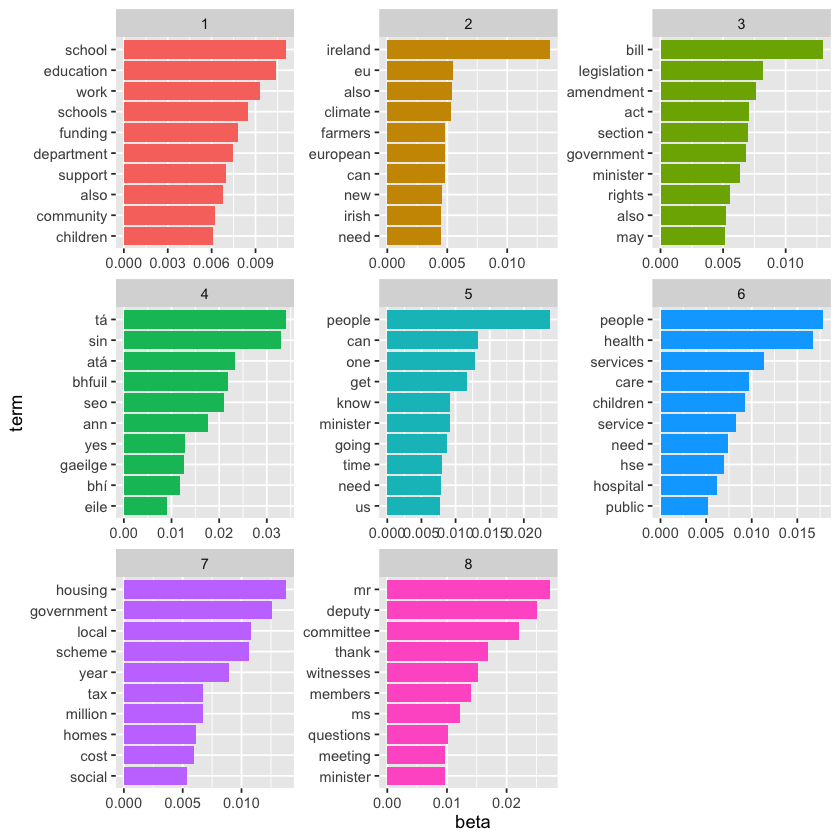

In [7]:
top_terms %>% #here I am plotting the above code to visualize potential topics. 
  mutate(term = reorder_within(term, beta, topic)) %>%
  ggplot(aes(beta, term, fill = factor(topic))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ topic, scales = "free") +
  scale_y_reordered()

The LDA model has provided eight topics. First, based on the terms, this topic is about schools, children, and education. The second topic is agriculture, with topics around farmers, the EU, and climate. The third topic is words referring to bills and legislation, not necessarily substantive in terms of determining political topics. Fourth, words in Irish, demonstrating either topics surrounding Irish or just the presence of the Irish language in Dáil debates. Five does not represent a topic; rather, it is a debate filler word. Topic six seems to concern health services and healthcare. Seven is most likely referring to housing. Finally, topic eight is once again not substantive to modelling political topics but rather just common words used in debate. 


In [28]:
theta <- as.data.frame(round(modeltools::posterior(lda_model)$topics, 2))
#Here I am aiming to group topics by party.
lda_model_8 <- cbind(
    debatesam[, "party", drop = FALSE],
    theta
)
lda_model_8 <- na.omit(lda_model_8)
lda_party <- aggregate(.~ party, data= lda_model_8, mean)
lda_party

party,1,2,3,4,5,6,7,8
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Anti-Austerity Alliance - People Before Profit,0.10217848,0.09755906,0.1106299,0.03388451,0.2753281,0.09498688,0.1190289,0.1682415
Fianna Fáil,0.09113134,0.09319644,0.1273925,0.04823324,0.2458776,0.09602480,0.1120961,0.1871639
Fine Gael,0.09147541,0.09287796,0.1168169,0.04062386,0.2594718,0.09522313,0.1179554,0.1867714
Green Party,0.08796185,0.09501004,0.1216064,0.03908635,0.2608835,0.10068273,0.1157129,0.1803213
Independent,0.09041597,0.11000832,0.1209900,0.04406822,0.2471298,0.09400166,0.1114559,0.1836356
Independents 4 Change,0.04875000,0.13375000,0.1291667,0.03416667,0.2145833,0.10291667,0.0925000,0.2433333
Labour Party,0.09052342,0.10454545,0.1314876,0.06046832,0.2421488,0.08721763,0.1038843,0.1808540
Sinn Féin,0.08427613,0.10397633,0.1198698,0.03940434,0.2574201,0.09184615,0.1121775,0.1920237
Social Democrats,0.08417559,0.09702355,0.1227623,0.04107066,0.2308351,0.08558887,0.1268308,0.2131049


By aggregating LDA topics by party, I can clearly identify how relevant each topic is to each party. For example, all parties generally discuss topics relevant to children and educational services, except Independents 4 Change. All parties are equally concerned with topic three, which refers to agriculture, but the top three parties discussing it most are Independents 4 Change, Labour Party, and Independent Ireland. Topic four, which references the Irish language many times as well as the EU and Europe as a whole, is mostly by the Labour Party; however, this category is just lower than the first three. Topic six, concerning healthcare, is most often referred to by Independents 4 Change and the Green Party; however, it is also a popular topic amongst the other parties. Finally, the last substantial topic that surrounds housing is a very popular one, with all parties roughly equally referring to it. 

In [9]:
topic_per_d <- tidy(lda_model, matrix = "gamma")
topic_per_d

document,topic,gamma
<chr>,<int>,<dbl>
text188942,1,0.0004638314
text134058,1,0.0219599771
text124022,1,0.0120361236
text226318,1,0.0276549555
text365209,1,0.0011862156
text193627,1,0.5097610111
text569692,1,0.0038266505
text589449,1,0.2361469272
text497690,1,0.0019081840


In [10]:
topic_counts <- topic_per_d %>%
  group_by(document) %>%
  slice_max(gamma, n = 1) %>%
  ungroup() %>%
  count(topic, sort = TRUE)
topic_counts

topic,n
<int>,<int>
5,4004
8,2827
3,1824
7,1711
2,1357
6,1327
1,1182
4,548


The first three topics are not particular substantive terms in terms of modeling, as they are common types of words used during debates, but the most commonly referred-to politically substantive terms are housing, agriculture, farming, and healthcare.

First, I reorganized the lda to assign each document to a topic. Afterwards, I decided to organize by topic counts. By doing this, it is revealed that the most discussed topic outside of the filler words is infrastructure and urban development. The second most common topic is writing and drafting legislation. The third most-debated topic in the Dail concerns the labor sector. 

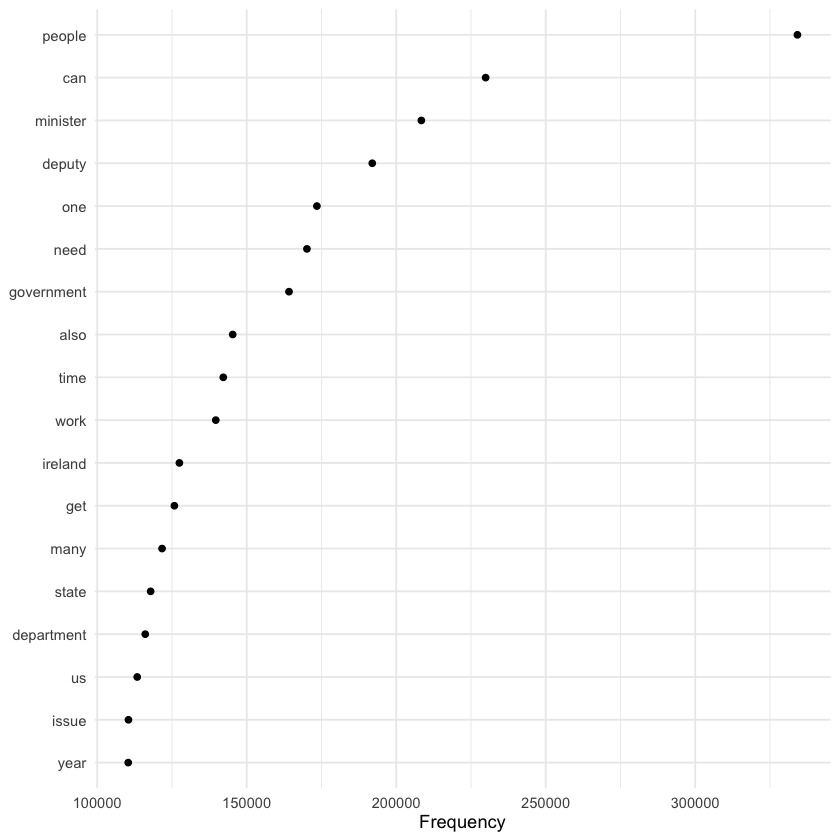

In [26]:
dtm %>% 
  textstat_frequency(n = 18) %>% #plotting test frequency
  ggplot(aes(x = reorder(feature, frequency), y = frequency)) +
  geom_point() +
  coord_flip() +
  labs(x = NULL, y = "Frequency") +
  theme_minimal()

I also wanted to see if any topics could be drawn from mapping the frequency of the top words. However, most of them are common logistical words. I found that the most frequent term by a long shot is people. However, there is not enough relevant information to draw any conclusions about the topics. 


# Part Two: Ideology Modelling

In [25]:
data("data_dictionary_LaverGarry") #loading dictionary

summary(data_dictionary_LaverGarry) #viewing dictionary

Dail_speech <- quanteda::dfm( #combining into a dfm
  quanteda::tokens_lookup(ddebates, dictionary = data_dictionary_LaverGarry)
)
Dail_speech

speech_df <- convert(Dail_speech, to = "data.frame") # converting to a dataframe

speech_df$party <- ddebate$party
speech_df$text <- ddebate$text # adding relevant features.
speech_df$ntokens <- ntoken(ddebates) #counting tokens

head(speech_df)

cols <- setdiff(names(speech_df), c("doc_id", "party"))
speech_df <- speech_df %>% #selecting specific sentiments of interest. 
  select("environment.pro environment", "environment.con environment" , 
         "values.conservative", "values.liberal", "law_and_order.law-conservative",
         "law_and_order.law-liberal", "party", "text", "ntokens")
speech_ideo <- speech_df %>%
  summarise( #calculating individual frequencies. 
    env_pro = sum(`environment.pro environment`)/ sum(ntokens) * 1000,
    env_con = sum(`environment.con environment`)/ sum(ntokens) * 1000,
    values_con = sum(`values.conservative`)/ sum(ntokens) * 1000,
    values_lib = sum(`values.liberal`)/ sum(ntokens) * 1000,
    law_lib = sum(`law_and_order.law-liberal`)/ sum(ntokens) * 1000,
    law_con = sum(`law_and_order.law-conservative`)/ sum(ntokens) * 1000
)

              Length Class       Mode     
CULTURE        3     dictionary2 list     
ECONOMY        3     dictionary2 list     
ENVIRONMENT    2     dictionary2 list     
GROUPS         2     dictionary2 list     
INSTITUTIONS   3     dictionary2 list     
LAW_AND_ORDER  2     dictionary2 list     
RURAL         16     -none-      character
URBAN          1     -none-      character
VALUES         2     dictionary2 list     

Document-feature matrix of: 591,949 documents, 20 features (87.69% sparse) and 0 docvars.
       features
docs    culture.culture-high culture.culture-popular culture.sport culture
  text1                    0                       0             0       0
  text2                    0                       0             0       0
  text3                    3                       0             0       2
  text4                    0                       0             0       0
  text5                    0                       0             0       0
  text6                    0                       0             0       0
       features
docs    economy.+state+ economy.=state= economy.-state-
  text1               0               1               0
  text2               8               3               1
  text3               2              15              10
  text4               5              18               5
  text5               0               0               0
  text6          

doc_id culture.culture-high culture.culture-popular culture.sport culture
1 text1  0                    0                       0             0      
2 text2  0                    0                       0             0      
3 text3  3                    0                       0             2      
4 text4  0                    0                       0             0      
5 text5  0                    0                       0             0      
6 text6  0                    0                       0             0      
  economy.+state+ economy.=state= economy.-state- environment.con environment
1 0                1               0              0                          
2 8                3               1              0                          
3 2               15              10              0                          
4 5               18               5              0                          
5 0                0               0              0                          
6 0                0               0              0                          
  environment.pro environment ⋯ institutions.radical
1 0                           ⋯ 0                   
2 0                           ⋯ 0                   
3 0                           ⋯ 1                   
4 0                           ⋯ 0                   
5 0                           ⋯ 0                   
6 0                           ⋯ 0                   
  law_and_order.law-conservative law_and_order.law-liberal rural urban
1 0                              0                         0     0    
2 0                              0                         0     0    
3 0                              0                         0     0    
4 0                              0                         0     0    
5 0                              0                         0     0    
6 0                              0                         0     0    
  values.conservative values.liberal party      
1 0                   0              Independent
2 1                   0              Independent
3 1                   0              Fine Gael  
4 0                   0              Fianna Fáil
5 0                   0              Independent
6 0                   0              Independent
  text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [24]:
party_leaning <- speech_df %>%
  group_by(party) %>%
  summarise(
    env_pro = sum(`environment.pro environment`)/ sum(ntokens) * 1000, #calcualting frequencies of the various senitements. 
    env_con = sum(`environment.con environment`)/ sum(ntokens) * 1000,
    values_con = sum(`values.conservative`)/ sum(ntokens) * 1000,
    values_lib = sum(`values.liberal`)/ sum(ntokens) * 1000,
    law_lib = sum(`law_and_order.law-liberal`)/ sum(ntokens) * 1000,
    law_con = sum(`law_and_order.law-conservative`)/ sum(ntokens) * 1000,
  )
party_leaning

party,env_pro,env_con,values_con,values_lib,law_lib,law_con
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Anti-Austerity Alliance - People Before Profit,3.050054,1.2584677,3.463563,3.213236,0.04613527,5.828423
Fianna Fáil,1.622139,0.8472175,2.822376,1.159858,0.02553380,5.021697
Fine Gael,1.621466,0.7140135,3.022104,1.440866,0.04159801,5.551365
Green Party,3.751795,0.7929561,3.326615,1.224470,0.03285839,3.311967
Independent,2.472198,0.8276799,2.734967,1.727543,0.03252517,5.204027
Independents 4 Change,2.858420,0.3737934,2.535932,1.978906,0.05130498,6.156597
Labour Party,1.642482,0.7826641,3.424677,2.242339,0.05560668,6.038191
Sinn Féin,1.568523,0.6538833,2.587976,1.512931,0.03822947,5.621007
Social Democrats,2.516602,0.6956339,3.387271,2.845638,0.04507347,5.196220


In [23]:

party_leaning <- party_leaning %>% # organizing overall scores and individual frequencies by party. 
  mutate(
    val_score = values_con / (values_con  + values_lib),
    env_score = env_pro/ (env_pro + env_con),
    law_score = law_lib / (law_lib + law_con)
)
party_leaning
  

party,env_pro,env_con,values_con,values_lib,law_lib,law_con,val_score,env_score,law_score
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Anti-Austerity Alliance - People Before Profit,3.050054,1.2584677,3.463563,3.213236,0.04613527,5.828423,0.5187460,0.7079120,0.007853403
Fianna Fáil,1.622139,0.8472175,2.822376,1.159858,0.02553380,5.021697,0.7087418,0.6569075,0.005058972
Fine Gael,1.621466,0.7140135,3.022104,1.440866,0.04159801,5.551365,0.6771509,0.6942755,0.007437561
Green Party,3.751795,0.7929561,3.326615,1.224470,0.03285839,3.311967,0.7309499,0.8255226,0.009823648
Independent,2.472198,0.8276799,2.734967,1.727543,0.03252517,5.204027,0.6128764,0.7491786,0.006211180
Independents 4 Change,2.858420,0.3737934,2.535932,1.978906,0.05130498,6.156597,0.5616883,0.8843537,0.008264463
Labour Party,1.642482,0.7826641,3.424677,2.242339,0.05560668,6.038191,0.6043174,0.6772714,0.009125128
Sinn Féin,1.568523,0.6538833,2.587976,1.512931,0.03822947,5.621007,0.6310740,0.7057769,0.006755235
Social Democrats,2.516602,0.6956339,3.387271,2.845638,0.04507347,5.196220,0.5434494,0.7834425,0.008599685


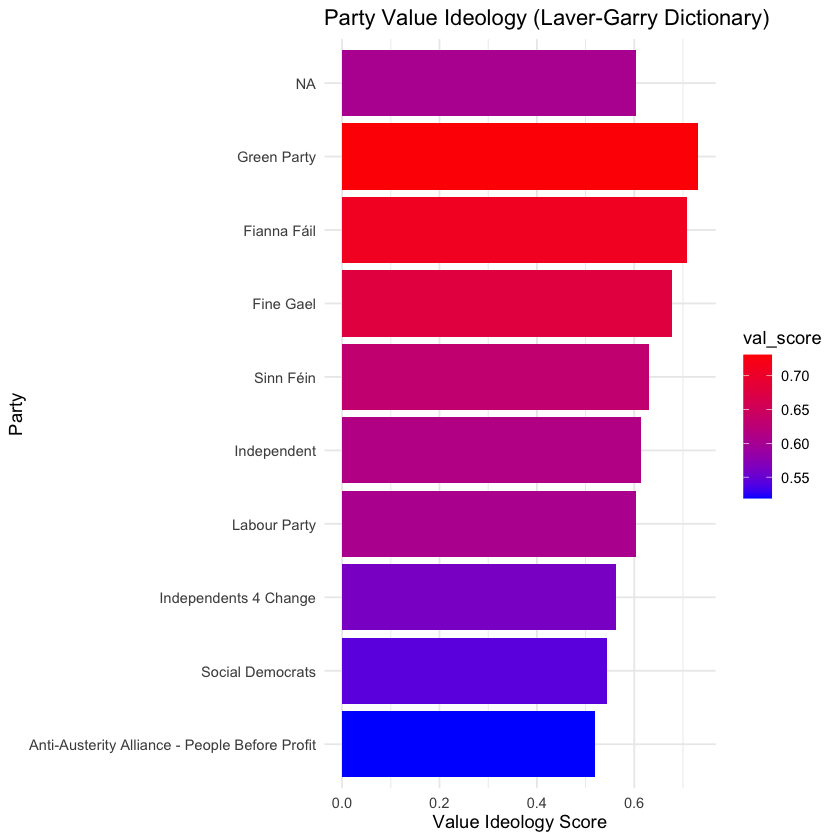

In [22]:
ggplot(party_leaning, aes(x = reorder(party, val_score), y = val_score, fill = val_score)) + #plotting value scores by party
    geom_col()+
coord_flip() +
scale_fill_gradient(low = "blue", high = "red") +
labs(
    x = "Party",
    y = "Value Ideology Score",
    title = "Party Value Ideology (Laver-Garry Dictionary)"
) +
theme_minimal()
                          

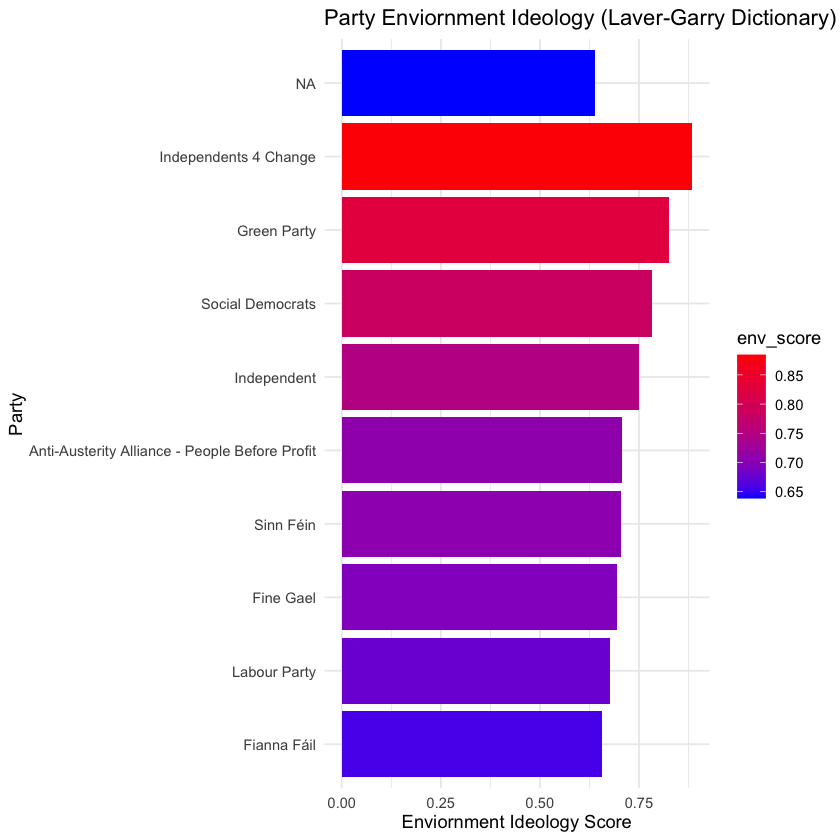

In [21]:
ggplot(party_leaning, aes(x = reorder(party, env_score), y = env_score, fill = env_score)) +  #plotting envionrment scores by party
    geom_col()+
coord_flip() +
scale_fill_gradient(low = "blue", high = "red") +
labs(
    x = "Party",
    y = "Enviornment Ideology Score",
    title = "Party Enviornment Ideology (Laver-Garry Dictionary)"
) +
theme_minimal()

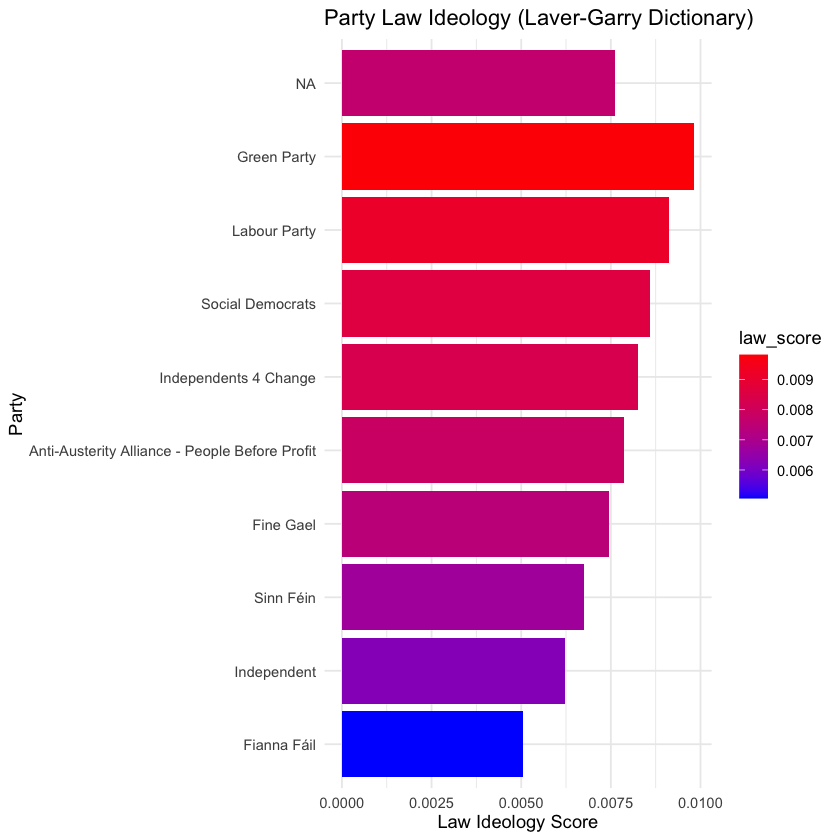

In [19]:
ggplot(party_leaning, aes(x = reorder(party, law_score), y = law_score, fill = law_score)) +
    geom_col()+
coord_flip() +
scale_fill_gradient(low = "blue", high = "red") +
labs(
    x = "Party",
    y = "Law Ideology Score",
    title = "Party Law Ideology (Laver-Garry Dictionary)"
) +
theme_minimal()

These graphs demonstrate that, first, for the value score, the parties are generally more conservative-leaning, with People Before Profit and Social Democrats having the lowest conservative values. This dictionary also indicates that Independents 4 Change and the Green Party have the most pro-environment rhetoric. Finally, Green has the most liberal law framing among the other parties; however, this dictionary indicates that all parties generally lean conservatively on the law. 


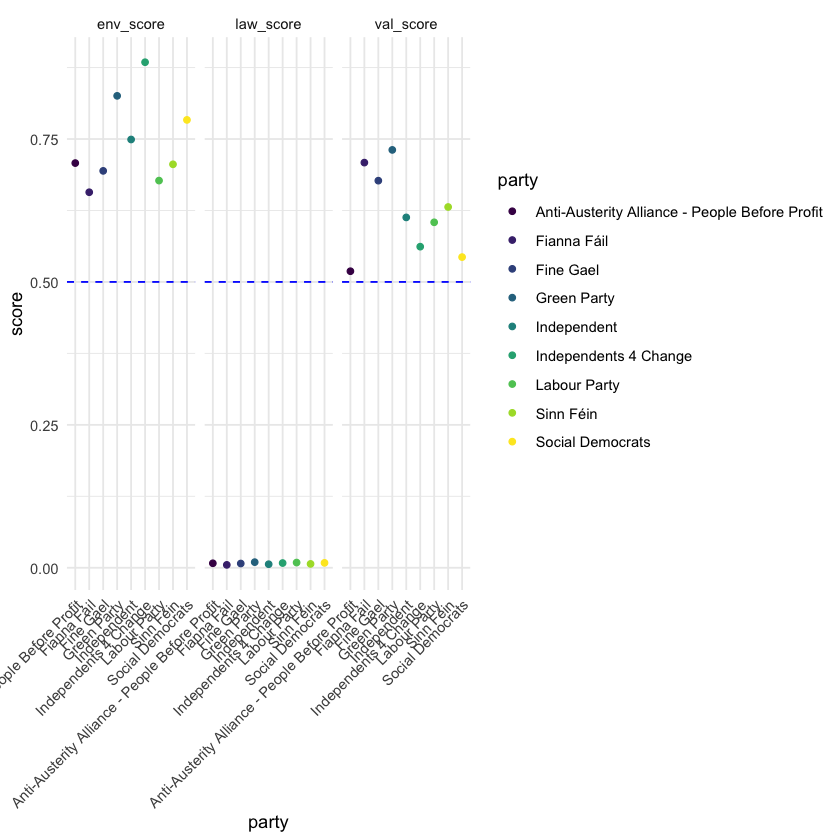

In [20]:
party_leaning %>% #creating a graph to visualize overall scores
  select(party, val_score, env_score, law_score) %>%
  pivot_longer(cols = c(val_score, env_score, law_score),
               names_to = "dimension", values_to = "score") %>%
  na.omit() %>%
  ggplot(aes(x = party, y = score, color = party)) +
  geom_point() +
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "blue") +
  facet_wrap(~dimension) +
  scale_color_viridis_d() +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

This demonstrates the general ideological leanings of all the parties in the Dail debates. It reaffirms that all parties lean conservatively toward the law but lean liberally toward values and the environment. 


## General Overview 

The outcomes of ideology modelling using the Laver-Garry dictionary might not be ideal for modelling the various ideologies in Irish political debates. By solely using this dictionary and having no prior knowledge of Irish politics, it would be easy to conclude that there is not much difference in thought between Irish politics, which is the opposite of true. Given that the dictionary is based in the UK, I originally thought that the application to Irish politics would be rather seamless, given the proximity; however, this does not accurately capture the various parties in Ireland or the ideological differences between them. This may be due to differences in Irish politics, in relevant terms, and in material conditions. Overall, I think seeing that all parties generally have liberal environmental leanings makes sense; however, I don't think all Irish parties should lean liberal on values. For example, with background knowledge, I know that Independent Ireland is a rather conservative party, so seeing that they have liberal values, as the dictionary states, does not make sense. Given that this dictionary was built around manifestos, applying them to debates may not be correct. For example, characterizing very left-leaning parties as conservative on law can be attributed to citing conservative rhetoric or debating against certain topics and sentiments. 
